# 020 bis — Training: the base architectures on the mockup-free generic split

One last ablation. This notebook is a byte-for-byte copy of the `020_training.ipynb`
training procedure — same architectures, same Round 1 recipe, same
`combined_loss`, same per-architecture subprocess — with **only the dataset
changed**. The standard split (`mockup_aware_train_val_test_split`) does two
things this one deliberately undoes:

| | standard split (`020`) | generic split (this notebook) |
|---|---|---|
| mockup groups (`settings.MOCKUP_ARTWORK_IDS`) | kept, split at pair level into train/val/test | **excluded entirely** — never seen |
| real artworks | grouped: every section of a painting stays in one fold | **ungrouped**: plain pair-level random split |
| folds | train / val / test | **train / val only** (no held-out test) |
| same artwork in val *and* elsewhere | prevented | **allowed** |

The split logic lives in `scripts.dataset.mockup_free_train_val_split`;
`scripts/train_single.py --generic-split` selects it inside each subprocess.
Checkpoints go to a **separate** tree, `models/deterministic_generic/<arch>/`,
so nothing here overwrites the project's real checkpoints.

Evaluation is **not** done here. `data/test/` (the GT-annotated paintings) is
untouched by either split, so it is the common yardstick — see
`C6_mockups_vs_generic.ipynb`, which loads whatever this notebook actually
trained and scores it against `models/deterministic/`.

Make the project root importable so `scripts.*` resolves regardless of the
notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check — identical to `020`
except for the split function imported.

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_free_train_val_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — mockup-free generic split

Every pair whose artwork ID is in `settings.MOCKUP_ARTWORK_IDS` is dropped.
The remaining real-artwork pairs are shuffled and cut into train / val at the
individual-pair level (`settings.VAL_RATIO`), with no grouping — sections of the
same painting will appear on both sides. There is no test split.

`crop_size` only affects the augmented training split; validation stays
full-image so the `val_loss` the checkpoint selects on is comparable to `020`'s.

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs = mockup_free_train_val_split(
    pairs,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")
excluded = sorted(settings.MOCKUP_ARTWORK_IDS)
print(f"Excluded mockup IDs: {excluded}")

2026-08-29 10:20:24.629016: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-29 10:20:24.629040: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-29 10:20:24.629046: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-29 10:20:24.629059: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-29 10:20:24.629068: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train: 652 patches (82 batches)
Val:   116 patches (15 batches)
Excluded mockup IDs: ['tbianco', 'tblu', 'tbruno', 'tgiallo', 'trosso', 'tverde']


## 2. Loss function

Unchanged from `020`: the unified `combined_loss` — `0.16 · Charbonnier +
0.84 · (1 − MS-SSIM)` (`fixing.md` #9). Nothing about the loss, optimizer, or
recipe differs here; the only variable under test is the training data.

## 3. Train the architectures

**Select which architectures to train by commenting lines in `ARCHS`.** The
companion `C6_mockups_vs_generic.ipynb` discovers whatever ended up with a
checkpoint under `models/deterministic_generic/` and compares exactly that set —
so a partial run here is fine, C6 adapts.

Each architecture trains in its own **subprocess** (`scripts/train_single.py
--generic-split`), for the same Apple-Silicon GPU-state reason as `020`.
Checkpoints and `history.json` go to `models/deterministic_generic/<arch>/`.
Set `EPOCHS = 2` for a quick smoke test first.

In [4]:
import json
import subprocess

ARCHS = [
    "resunet",
    "unet",
    "attention_unet",
    #"unet_residual",
]
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
MODEL_DIR = settings.MODELS_DIR / "deterministic_generic"
LOG_DIR = settings.LOGS_DIR / "deterministic_generic"

histories: dict = {}

for arch in ARCHS:
    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        arch,
        "--epochs",
        str(EPOCHS),
        "--model-dir",
        str(MODEL_DIR),
        "--log-dir",
        str(LOG_DIR),
        "--generic-split",
    ]
    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = MODEL_DIR / arch / "history.json"
    histories[arch] = json.loads(history_path.read_text())

    best_val_loss = min(histories[arch]["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

generic split (mockups excluded, ungrouped): train=652  val=116


2026-08-29 10:20:27.019700: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-29 10:20:27.019718: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-29 10:20:27.019723: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-29 10:20:27.019735: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-29 10:20:27.019743: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: resunet (combined_loss, alpha=0.16)
Model: "resunet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_1 │ (None, None,      │         128 │ conv2d_1[0][0]     │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼─────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-29 10:20:30.078604: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3862 - mae: 0.4045 - psnr: 8.5037 - ssim: 0.3609
Epoch 1: val_loss improved from None to 0.32267, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/resunet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/resunet/best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - loss: 0.3862 - mae: 0.4045 - psnr: 8.5037 - ssim: 0.3609 - val_loss: 0.3227 - val_mae: 0.3095 - val_psnr: 11.0443 - val_ssim: 0.4028 - learning_rate: 1.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.3079 - mae: 0.2063 - psnr: 14.8096 - ssim: 0.4089
Epoch 2: val_loss improved from 0.32267 to 0.27613, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/resunet/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - loss: 0.3518 - mae: 0.3180 - psnr: 11.0176 - ssim: 0.3982
Epoch 1: val_loss improved from None to 0.29649, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/unet/best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - loss: 0.3518 - mae: 0.3180 - psnr: 11.0176 - ssim: 0.3982 - val_loss: 0.2965 - val_mae: 0.2436 - val_psnr: 13.5559 - val_ssim: 0.4861 - learning_rate: 1.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 949ms/step - loss: 0.2955 - mae: 0.1927 - psnr: 15.2933 - ssim: 0.4964
Epoch 2: val_loss improved from 0.29649 to 0.26910, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/unet/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/un

2026-08-29 14:26:06.290960: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-29 14:26:06.290978: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-29 14:26:06.290982: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-29 14:26:06.290994: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-29 14:26:06.291004: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



  Architecture: attention_unet (combined_loss, alpha=0.16)
Model: "attention_unet"
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼──────��────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────

/opt/miniconda3/envs/deep-layers/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-08-29 14:26:08.965343: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.6073 - mae: 0.2100 - psnr: 12.8885 - ssim: 0.2539
Epoch 1: val_loss improved from None to 0.45888, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/attention_unet/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/attention_unet/best_model.keras
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - loss: 0.6073 - mae: 0.2100 - psnr: 12.8885 - ssim: 0.2539 - val_loss: 0.4589 - val_mae: 0.1832 - val_psnr: 14.4087 - val_ssim: 0.5107 - learning_rate: 1.0000e-04
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.4831 - mae: 0.1952 - psnr: 13.8160 - ssim: 0.5092
Epoch 2: val_loss did not improve from 0.45888
82/82 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - loss: 0.4831 - mae: 0.1952 - psnr: 13.8160 - ssim: 0.5092 - val_loss: 0.4861 - val_mae: 0.1908 - val_psnr: 14.0282 - val_ssim: 0.5428 - learning_rate: 1.0000e-04
Epoch 3/100
82/82 

## 4. Training curves

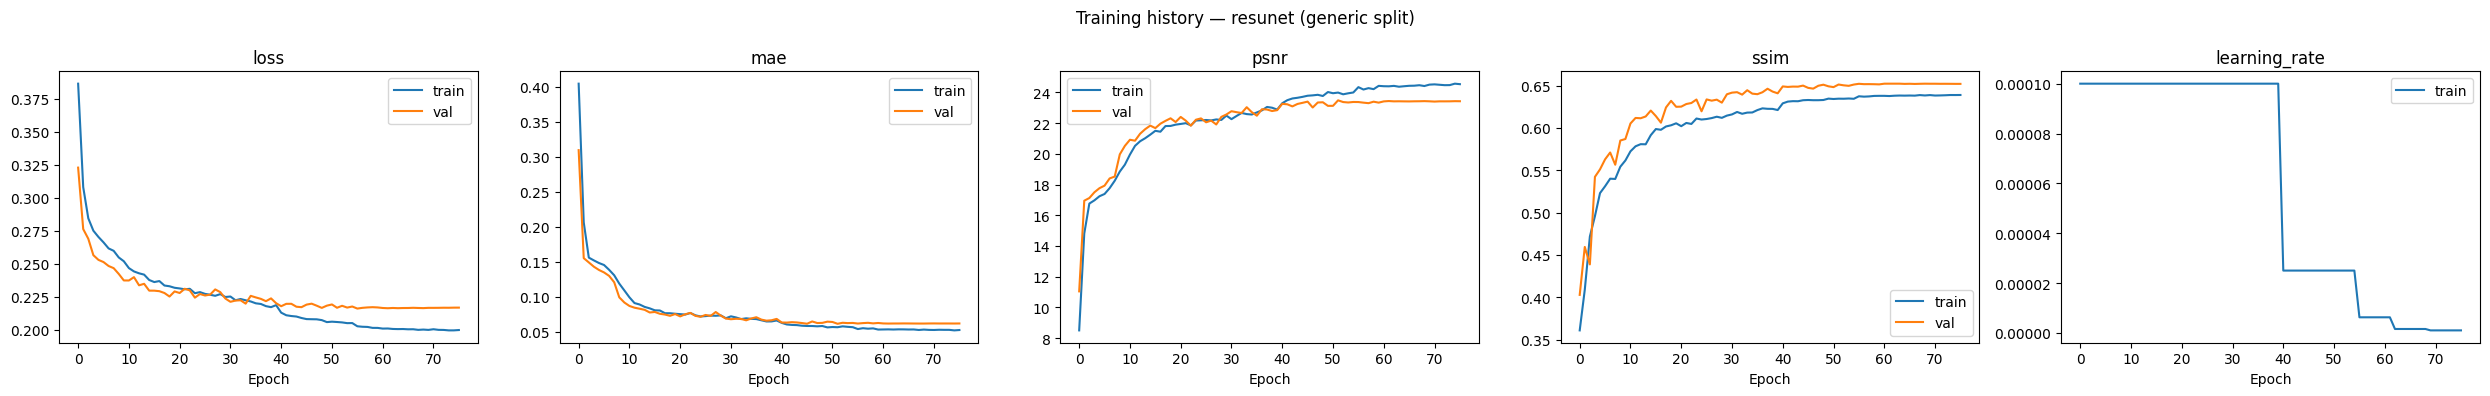

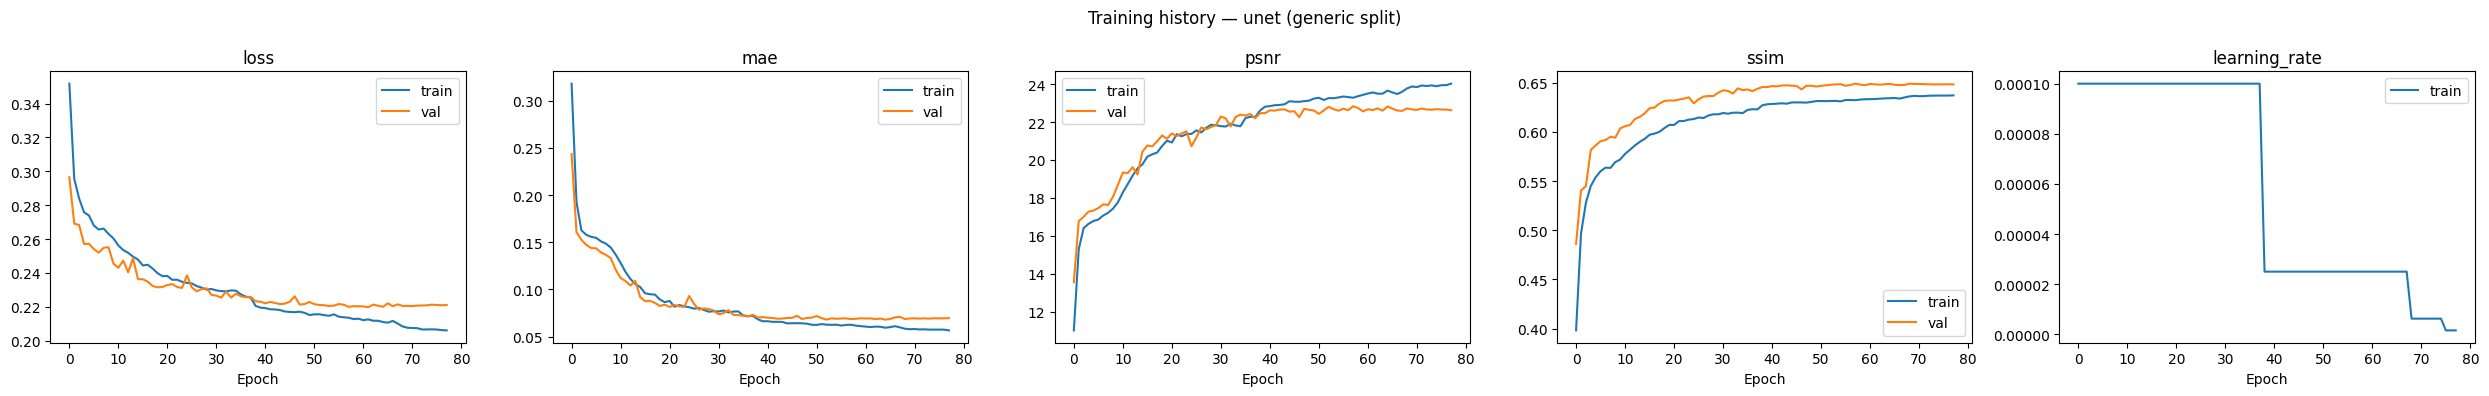

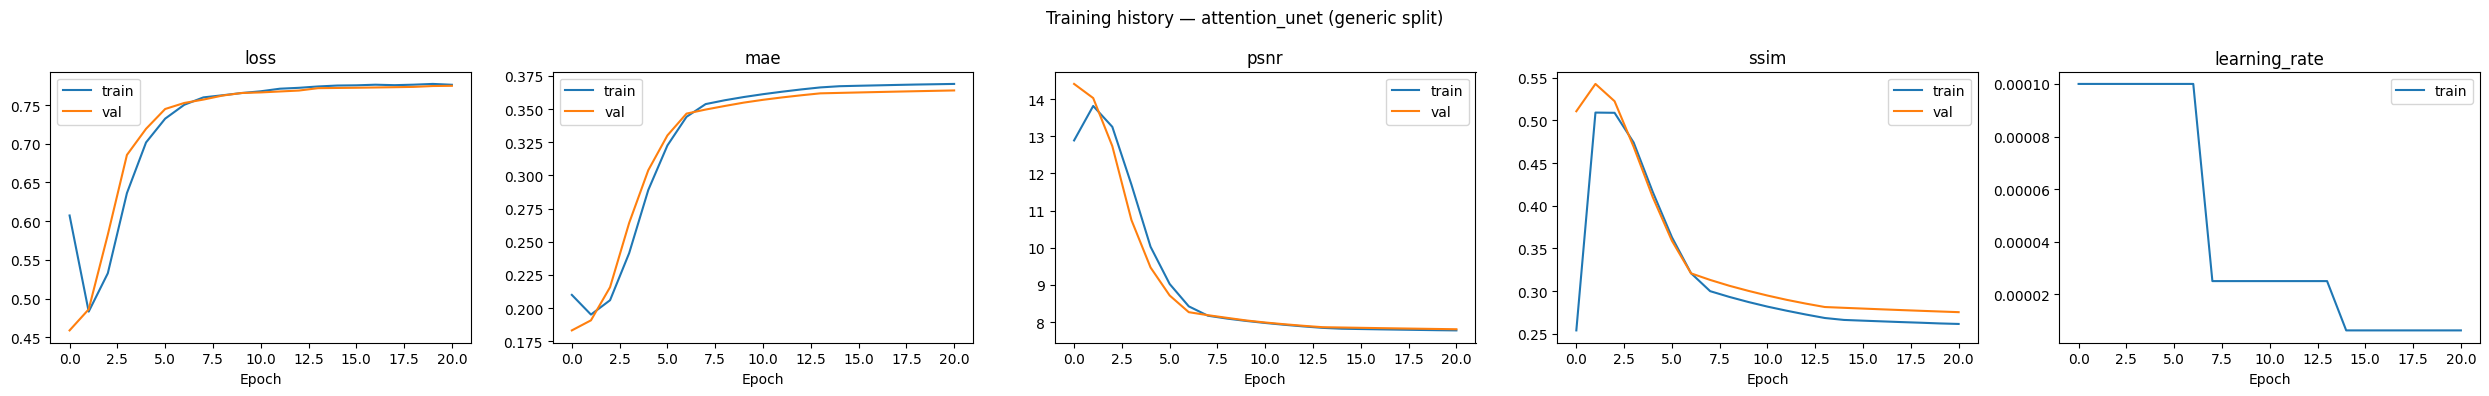

In [5]:
for arch, history in histories.items():
    plot_training_curves(history, title=f"Training history — {arch} (generic split)")
    plt.show()

## 5. Summary

Checkpoints saved to `models/deterministic_generic/<arch>/best_model.keras`.
Run `C6_mockups_vs_generic.ipynb` next to score them against the standard-split
checkpoints on `data/test/`.

In [6]:
for arch in ARCHS:
    ckpt = MODEL_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

resunet                  : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/resunet/best_model.keras)
unet                     : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/unet/best_model.keras)
attention_unet           : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic_generic/attention_unet/best_model.keras)
